## Fig 1 genes analysis 

Restricting the censat regions to count genes in to just the regions used in CHM13

In [1]:
import os
import glob
import pandas as pd

In [ ]:
### visualizing CHM13 arrays and the gene content. 

In [2]:
def map_to_sat_category(raw):
    if raw is None: return "other"
    if   re.match(r'active_hor', raw, re.I): return "active_hor"
    elif re.match(r'dhor',       raw, re.I): return "dhor"
    elif re.match(r'hor',        raw, re.I): return "hor"
    elif re.match(r'mixedalpha', raw, re.I): return "mixedAlpha"
    elif re.match(r'mon',        raw, re.I): return "mon"
    elif re.search(r'hsat1',     raw, re.I): return "HSAT1"
    elif re.search(r'hsat2',     raw, re.I): return "HSAT2"
    elif re.search(r'hsat3',     raw, re.I): return "HSAT3"
    elif re.search(r'hsat4',     raw, re.I): return "HSAT4"
    elif re.search(r'hsat5',     raw, re.I): return "HSAT5"
    elif re.match(r'bsat',       raw, re.I): return "bSat"
    elif re.match(r'gsat',       raw, re.I): return "gSat"
    elif re.match(r'ct',         raw, re.I): return "CT"
    elif re.search(r'satr',      raw, re.I): return "SATR"
    elif re.search(r'sst1',      raw, re.I): return "SST1"
    elif re.search(r'cer',       raw, re.I): return "CER"
    elif re.search(r'rdna|5srna',raw, re.I): return "rDNA"
    elif re.search(r'acro',      raw, re.I): return "acrocentric"
    else:                                     return "other"


In [3]:
import pandas as pd
import re

# ── censat BED ────────────────────────────────────────────────────────────────
censat_bed = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_beds/chm13v2.0_censat_v2.1.bed',
    sep='\t', header=None,
    names=['chrom','start','end','name','score','strand','thick_start','thick_end','rgb']
)
censat_bed['color'] = censat_bed['rgb'].apply(
    lambda x: tuple(int(v)/255 for v in x.split(','))
)
censat_bed['sat_cat'] = censat_bed['name'].apply(map_to_sat_category)

# ── genes TSV ─────────────────────────────────────────────────────────────────
genes_df = pd.read_csv(
    '/private/groups/patenlab/mira/databaseS08_GeneExpression.tsv',
    sep='\t', comment='#',
    names=['chrom','start','end','name','ensID','CATv4','gene_biotype',
           'novel','salmon','iso','rna_k21','pro_k21','between_satellites_nonacro']
)
genes_df['start'] = genes_df['start'].astype(int)
genes_df['end']   = genes_df['end'].astype(int)

print(f"censat rows: {len(censat_bed)}")
print(f"gene rows:   {len(genes_df)}")
print(f"gene biotypes: {genes_df['gene_biotype'].value_counts().head(6).to_dict()}")


censat rows: 2523
gene rows:   61497
gene biotypes: {'protein_coding': 19869, 'lncRNA': 17383, 'processed_pseudogene': 10523, 'unprocessed_pseudogene': 2573, 'misc_RNA': 2158, 'miRNA': 1897}


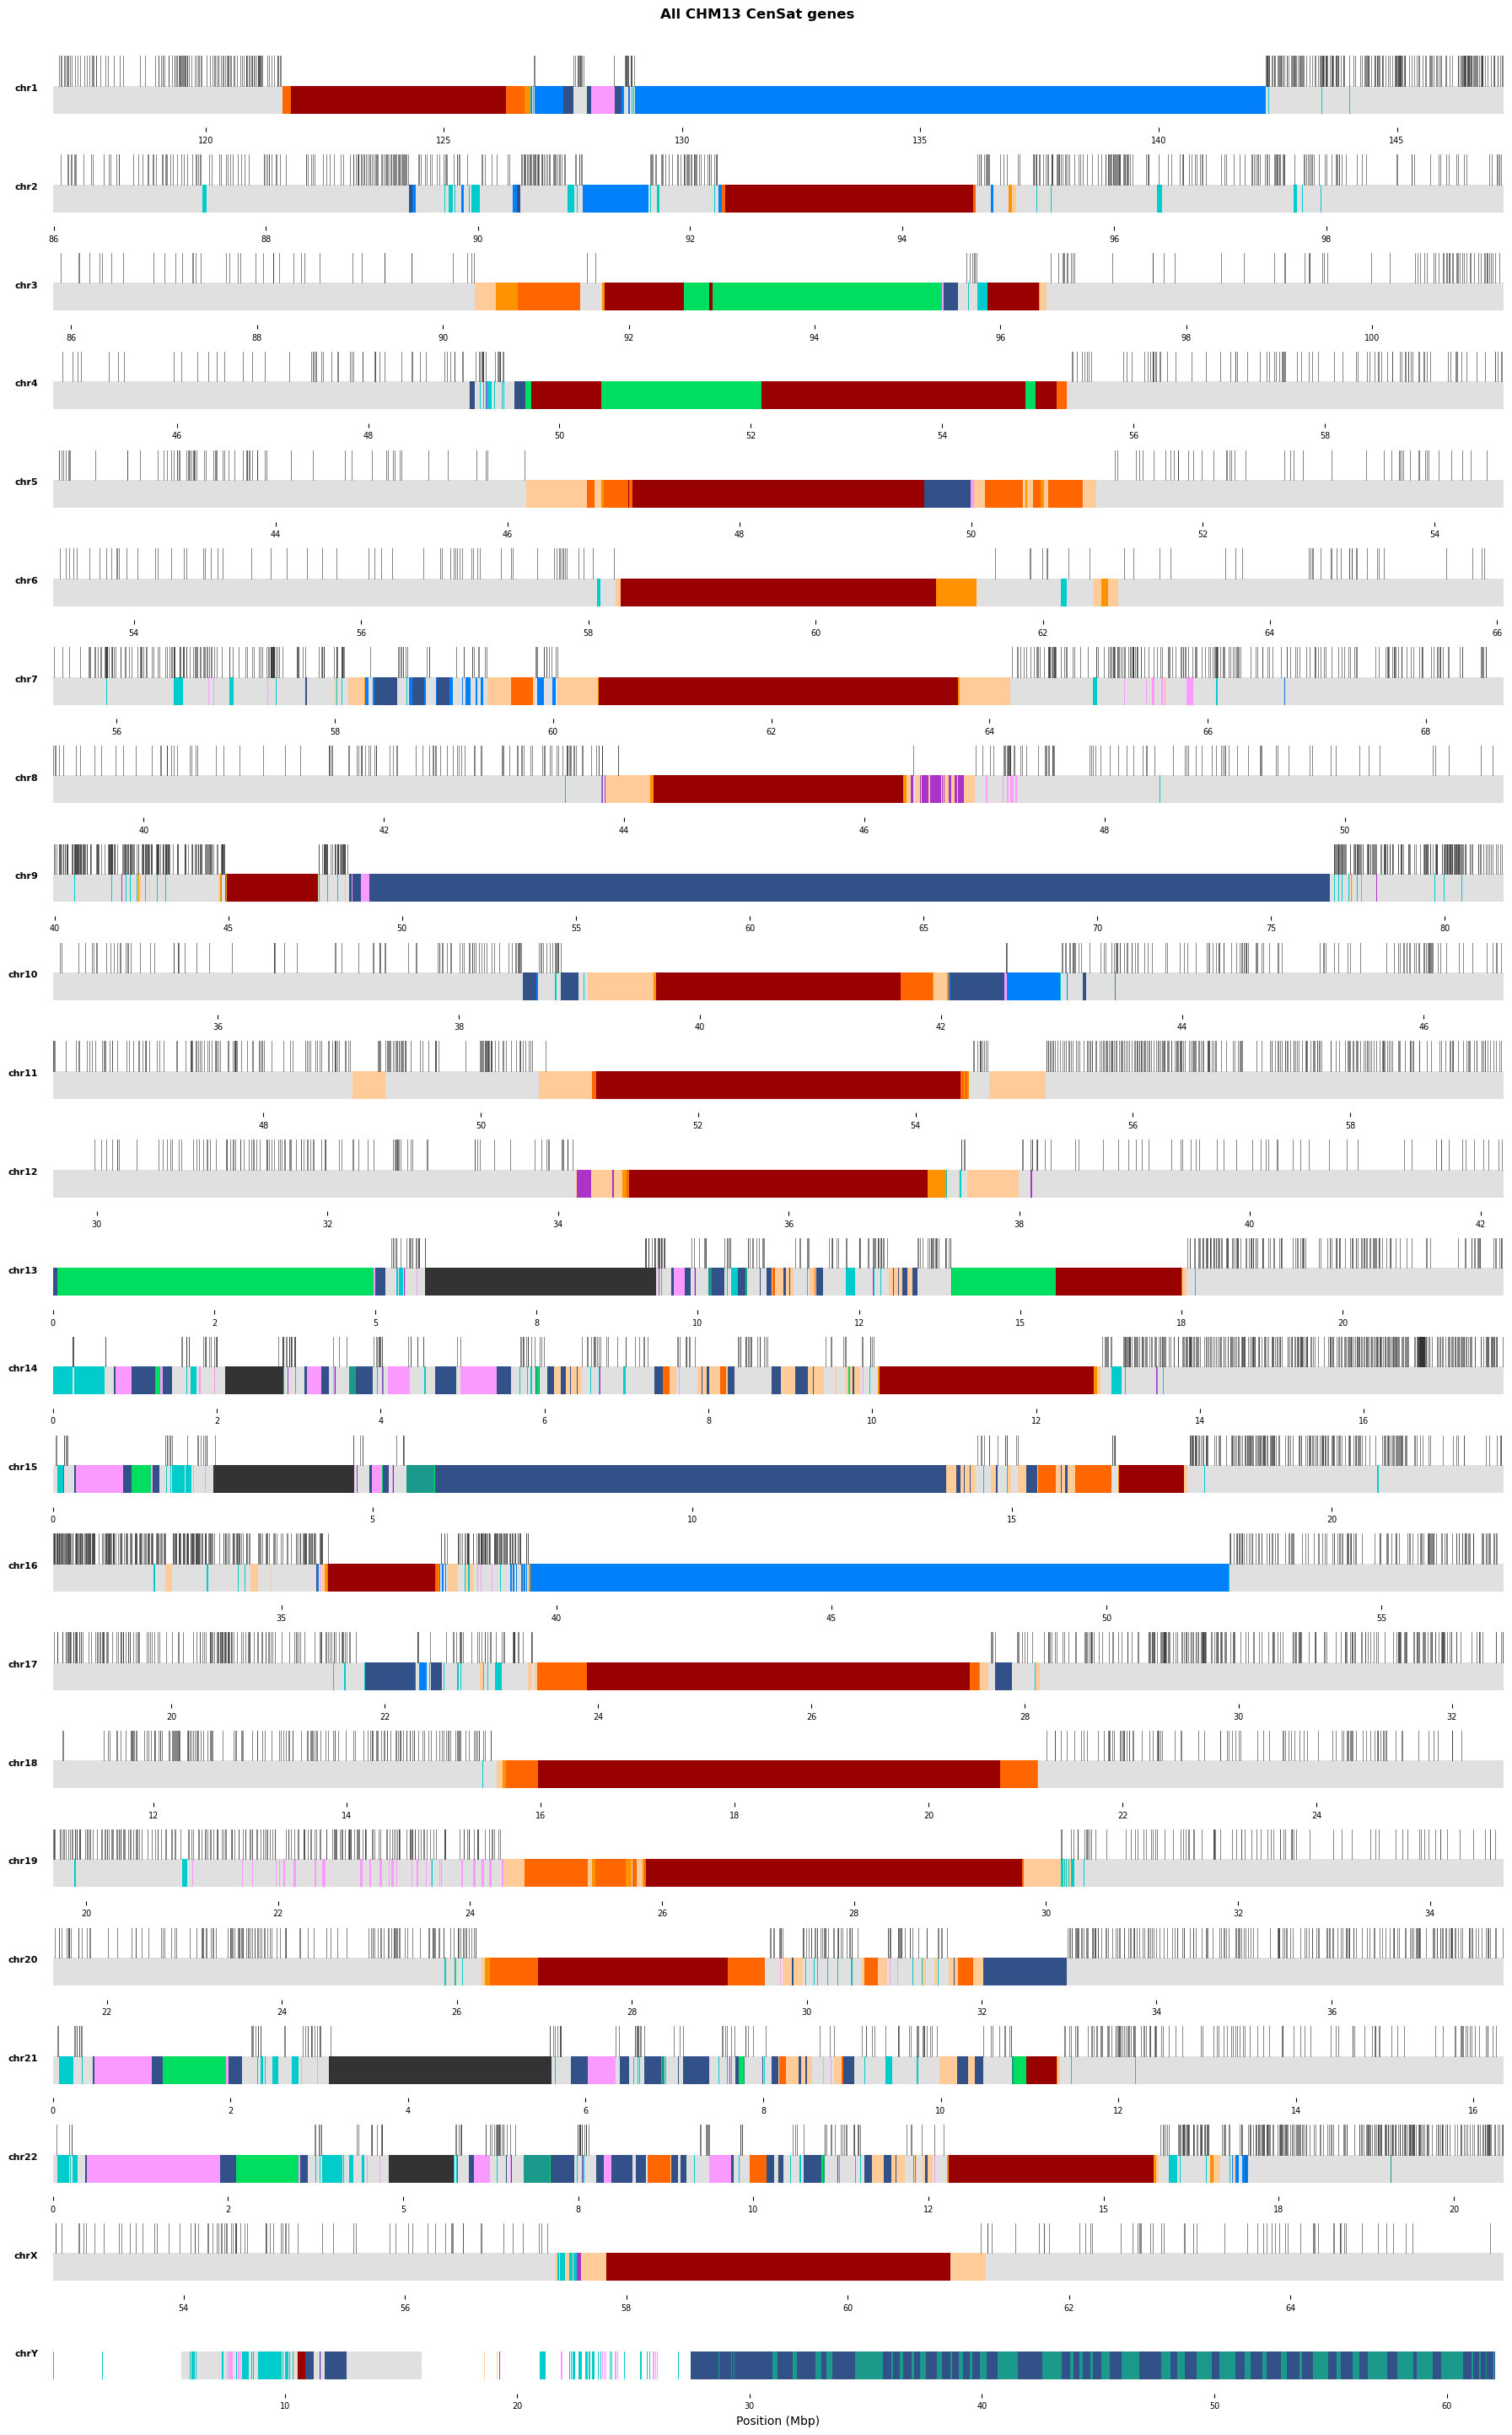

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

genes_filt = genes_df.copy()

ARRAY_H  = 0.35   # height of censat bar
GENE_Y   = 0.55   # y offset above array center for gene ticks
ROW_H    = 1.2    # total row height per chrom

fig, axes = plt.subplots(len(CHROM_ORDER), 1,
                         figsize=(18, len(CHROM_ORDER) * ROW_H),
                         squeeze=False)

for row_i, chrom in enumerate(CHROM_ORDER):
    ax = axes[row_i, 0]

    cbed = censat_bed[censat_bed['chrom'] == chrom]
    cgenes = genes_filt[genes_filt['chrom'] == chrom]

    if len(cbed) == 0:
        ax.set_visible(False)
        continue

    x_min, x_max = cbed['start'].min(), cbed['end'].max()

    # ── censat array bars ─────────────────────────────────────────────────────
    for _, seg in cbed.iterrows():
        ax.add_patch(mpatches.Rectangle(
            (seg['start'], -ARRAY_H/2), seg['end'] - seg['start'], ARRAY_H,
            color=seg['color'], linewidth=0
        ))

    # ── gene tick marks ───────────────────────────────────────────────────────
    for _, g in cgenes.iterrows():
        mid = (g['start'] + g['end']) / 2
        ax.plot([mid, mid], [ARRAY_H/2, GENE_Y],
                color='#333333', lw=0.6, alpha=0.7)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-ARRAY_H, GENE_Y + 0.1)
    ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}"))

    # chrom label on left
    ax.text(-0.01, 0.5, chrom, transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='center', ha='right')

axes[-1, 0].set_xlabel('Position (Mbp)', fontsize=10)
fig.suptitle('All CHM13 CenSat genes',
             fontsize=12, fontweight='bold', y=1.001)

plt.tight_layout(h_pad=0.2)

plt.show()


In [7]:
print(genes_df['between_satellites_nonacro'].value_counts())


between_satellites_nonacro
False    60821
True       676
Name: count, dtype: int64


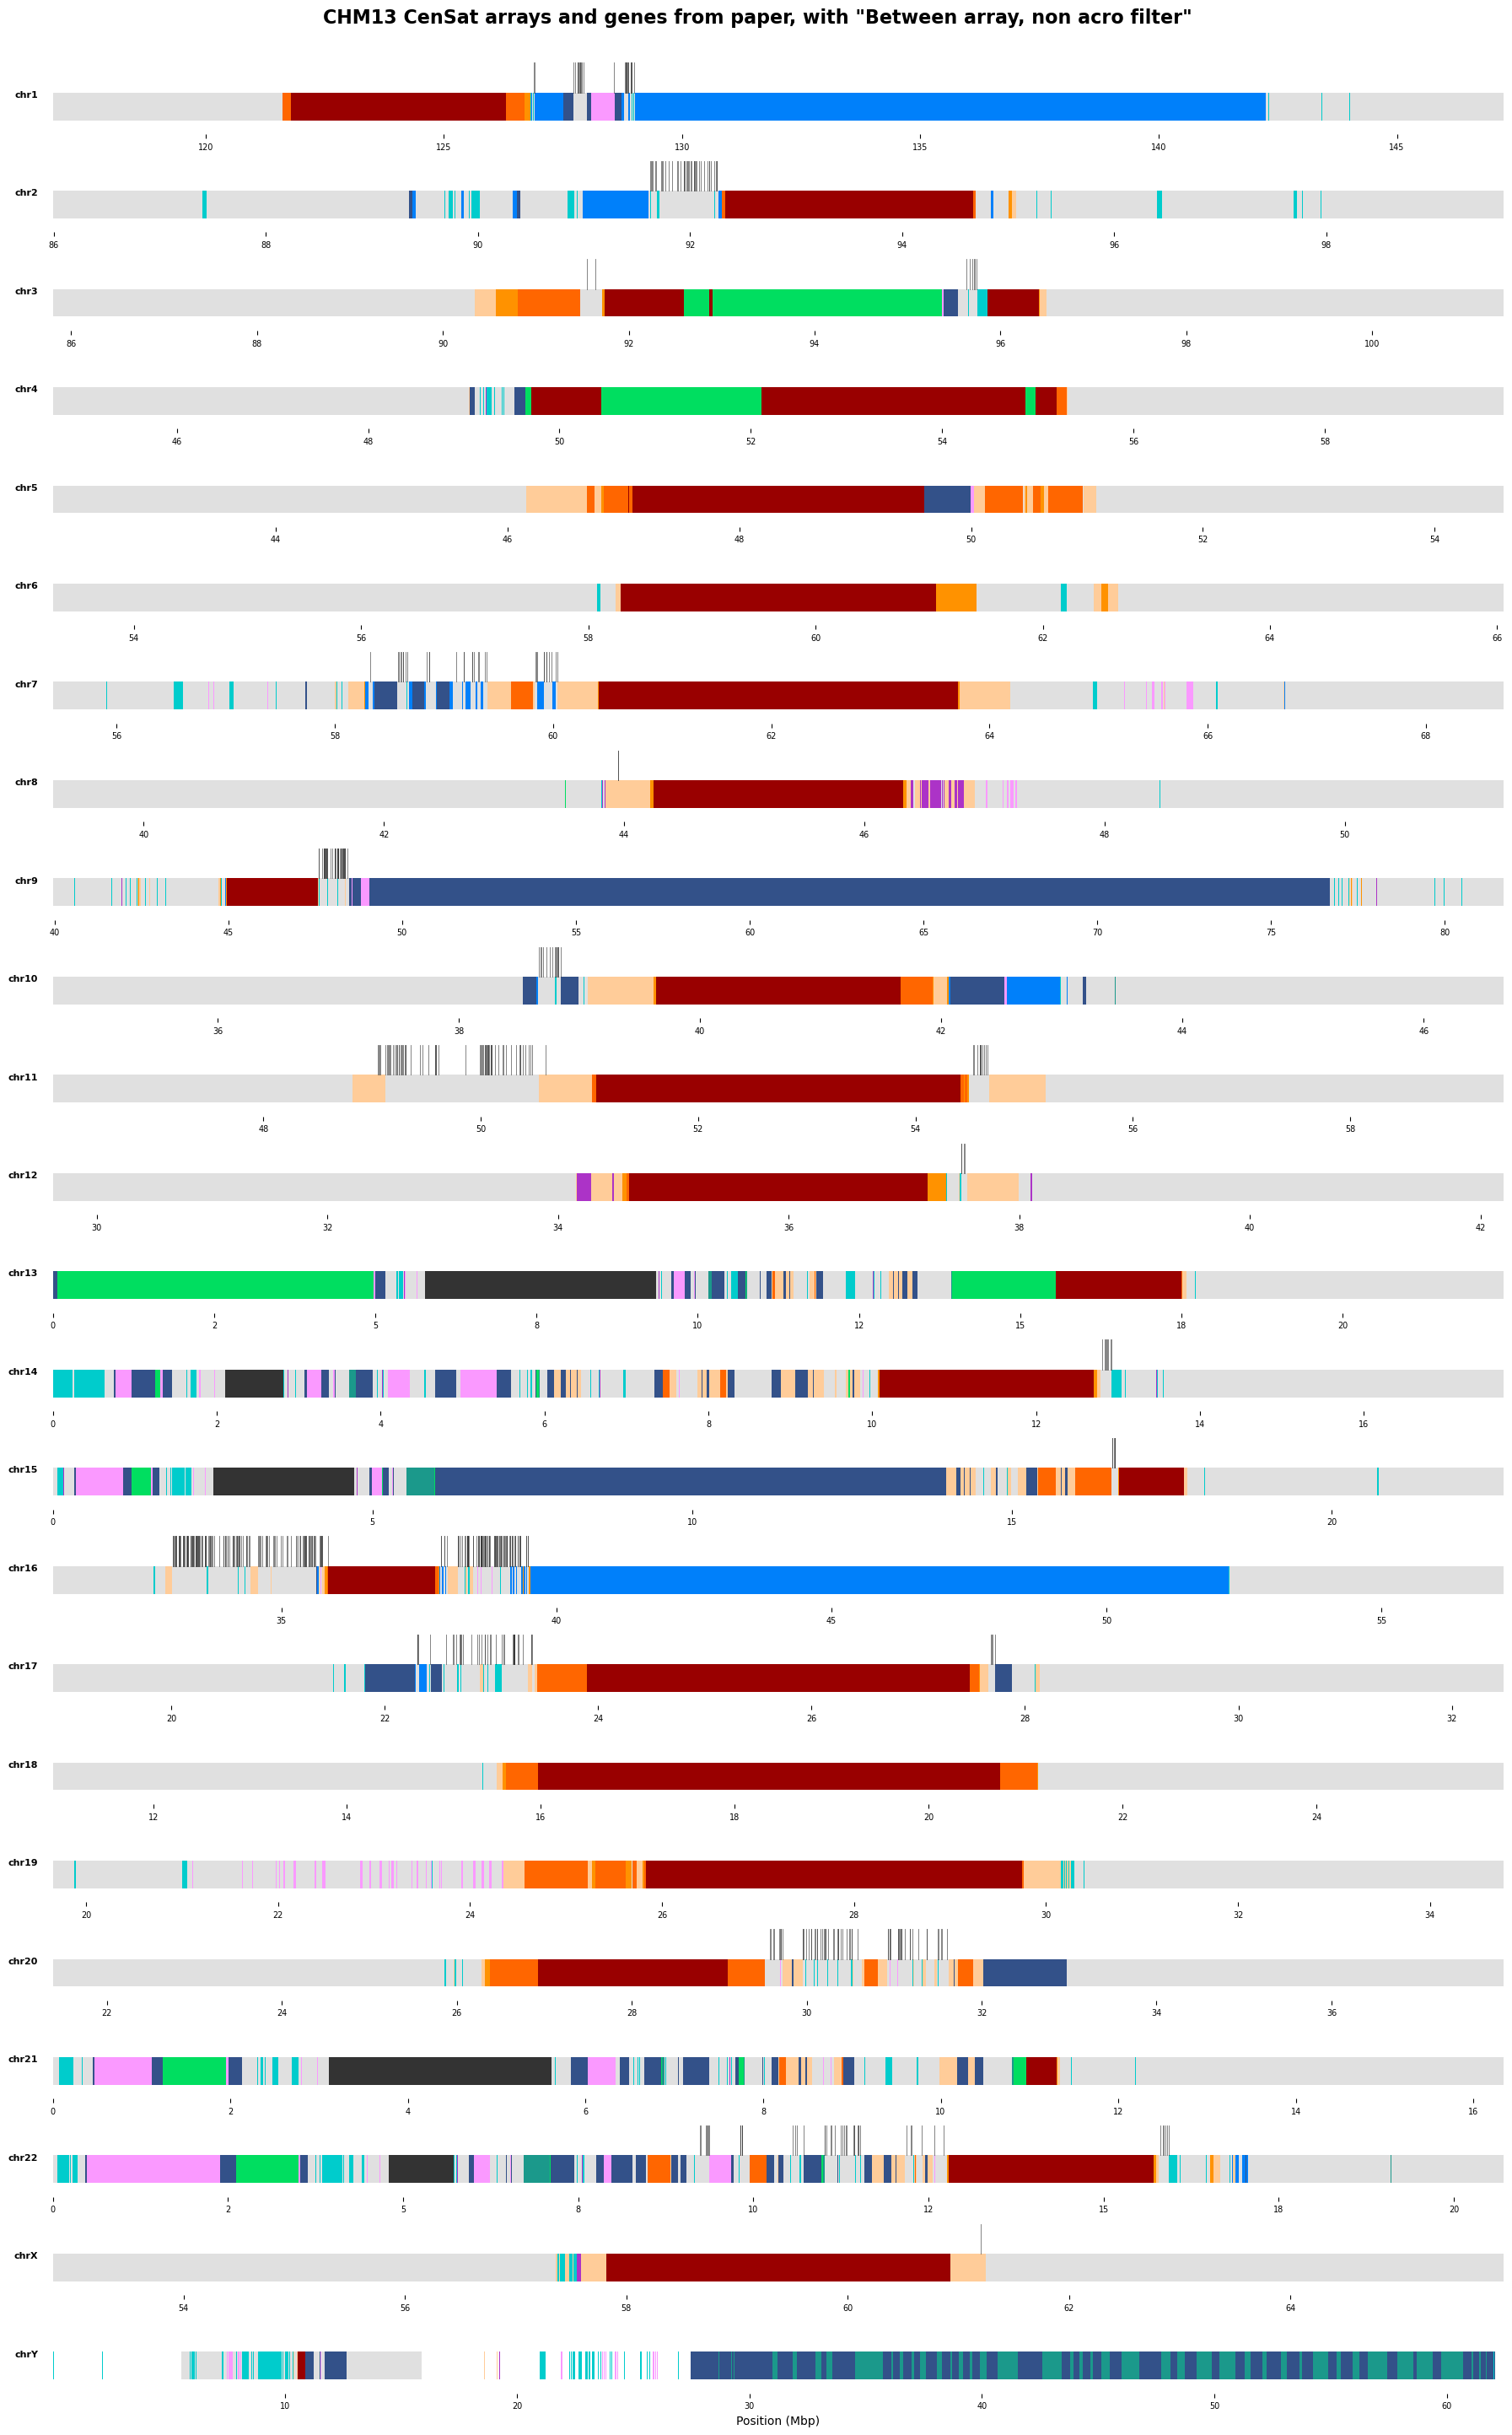

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

genes_filt = genes_df[genes_df['between_satellites_nonacro'] == True].copy()

ARRAY_H  = 0.35   # height of censat bar
GENE_Y   = 0.55   # y offset above array center for gene ticks
ROW_H    = 1.2    # total row height per chrom

fig, axes = plt.subplots(len(CHROM_ORDER), 1,
                         figsize=(18, len(CHROM_ORDER) * ROW_H),
                         squeeze=False)

for row_i, chrom in enumerate(CHROM_ORDER):
    ax = axes[row_i, 0]

    cbed = censat_bed[censat_bed['chrom'] == chrom]
    cgenes = genes_filt[genes_filt['chrom'] == chrom]

    if len(cbed) == 0:
        ax.set_visible(False)
        continue

    x_min, x_max = cbed['start'].min(), cbed['end'].max()

    # ── censat array bars ─────────────────────────────────────────────────────
    for _, seg in cbed.iterrows():
        ax.add_patch(mpatches.Rectangle(
            (seg['start'], -ARRAY_H/2), seg['end'] - seg['start'], ARRAY_H,
            color=seg['color'], linewidth=0
        ))

    # ── gene tick marks ───────────────────────────────────────────────────────
    for _, g in cgenes.iterrows():
        mid = (g['start'] + g['end']) / 2
        ax.plot([mid, mid], [ARRAY_H/2, GENE_Y],
                color='#333333', lw=0.6, alpha=0.7)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-ARRAY_H, GENE_Y + 0.1)
    ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}"))

    # chrom label on left
    ax.text(-0.01, 0.5, chrom, transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='center', ha='right')

axes[-1, 0].set_xlabel('Position (Mbp)', fontsize=10)
fig.suptitle('CHM13 CenSat genes, with "Between array, non acro filter"',
             fontsize=16, fontweight='bold', y=1.001)

plt.tight_layout(h_pad=0.2)

plt.show()


## CHM13 paper reported: All gene annotations occurring between any peri/centromeric satellite annotations larger than 100 kb, excluding acrocentric short arms

In [4]:
CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
CENSAT_TSV_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_arrays/tables/censat_regions_pass_qc_by_chrom'

In [5]:
# load array boundaries
all_tsvs = glob.glob(f'{CENSAT_TSV_DIR}/censat_regions_pass_qc_chr*.tsv')
regions_df = pd.concat([pd.read_csv(f, sep='\t') for f in all_tsvs], ignore_index=True)
regions_df = regions_df[regions_df['pass_qc'] == True][
    ['sample_id', 'haplotype', 'chrom_assignment', 'sequence_id', 'region_start', 'region_end', 'pass_qc']
].rename(columns={'chrom_assignment': 'chrom'})
regions_df['haplotype'] = regions_df['haplotype'].astype(str)

In [6]:
import glob, re, os
import pandas as pd

ANNOT_DIR = '/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/satellite_neighbors'

def parse_attr(attr_str, key):
    m = re.search(rf'{key}=([^;]+)', attr_str)
    return m.group(1) if m else None

records = []
for path in glob.glob(f'{ANNOT_DIR}/*_sat_neighbors.tsv'):
    fname = os.path.basename(path)
    m = re.match(r'(.+?)_(hap\d+|mat|pat)_(chr\w+)_sat_neighbors\.tsv', fname)
    if not m: continue
    sample_id = m.group(1)
    hap_raw   = m.group(2)
    chrom     = m.group(3)
    haplotype = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')

    df = pd.read_csv(path, sep='\t', header=0, low_memory=False)  # header=0: use first row
    df = df[df['feature'] == 'gene'].copy()

    df['sample_id']    = sample_id
    df['haplotype']    = haplotype
    df['chrom']        = chrom
    df['gene_name']    = df['attributes'].apply(lambda x: parse_attr(x, 'gene_name'))
    df['gene_biotype'] = df['attributes'].apply(lambda x: parse_attr(x, 'gene_biotype'))

    records.append(df[['sample_id', 'haplotype', 'chrom', 'contig',
                        'start', 'end', 'strand', 'gene_name', 'gene_biotype',
                        'between_satellites_100kb', 'on_acrocentric_short_arm']])

annot_df = pd.concat(records, ignore_index=True)
annot_df['start'] = annot_df['start'].astype(int)
annot_df['end']   = annot_df['end'].astype(int)

print(annot_df.shape)
display(annot_df.head())

(170894, 11)


,sample_id,haplotype,chrom,contig,start,end,strand,gene_name,gene_biotype,between_satellites_100kb,on_acrocentric_short_arm
0,NA19036,2,chr10,CM089743.1,38713766,38717957,+,ABCD1P2,unprocessed_pseudogene,True,False
1,NA19036,2,chr10,CM089743.1,38749985,38752159,+,PABPC1P12,processed_pseudogene,True,False
2,NA19036,2,chr10,CM089743.1,38755057,38803140,-,SLC9B1P3,transcribed_unprocessed_pseudogene,True,False
3,NA19036,2,chr10,CM089743.1,38810469,38811947,+,ACTR3BP5,processed_pseudogene,True,False
4,NA19036,2,chr10,CM089743.1,38827203,38833237,+,CHEK2P5,unprocessed_pseudogene,True,False


In [7]:
import os, glob, re

REGIONS_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_arrays/tables/censat_regions_pass_qc_by_chrom'

# Build set of (sample_id, normalized_hap, chrom) that pass QC
# normalized_hap: '1' or '2'
pass_qc = set()
for path in glob.glob(f'{REGIONS_DIR}/censat_regions_pass_qc_chr*.tsv'):
    m = re.match(r'.*censat_regions_pass_qc_(chr\w+)\.tsv', path)
    if not m: continue
    chrom = m.group(1)
    df_r = pd.read_csv(path, sep='\t', usecols=['sample_id', 'haplotype'])
    for _, row in df_r.iterrows():
        pass_qc.add((str(row['sample_id']), str(int(row['haplotype'])), chrom))

# Normalize haplotype in annot_df to '1'/'2' for matching
hap_norm = {'hap1': '1', 'hap2': '2', 'pat': '1', 'mat': '2',
            '1': '1', '2': '2'}

before = len(annot_df)
annot_df = annot_df[
    annot_df.apply(
        lambda r: (str(r['sample_id']),
                   hap_norm.get(str(r['haplotype']), str(r['haplotype'])),
                   r['chrom']) in pass_qc,
        axis=1)
].copy()
print(f"Rows before: {before:,}  →  after: {len(annot_df):,}")


Rows before: 170,894  →  after: 170,894


In [8]:
print(annot_df['between_satellites_100kb'].value_counts())
print(f"\nTRUE: {annot_df['between_satellites_100kb'].isin([True, 'TRUE']).sum():,}")
print(f"FALSE: {annot_df['between_satellites_100kb'].isin([False, 'FALSE']).sum():,}")


between_satellites_100kb
False    98836
True     72058
Name: count, dtype: int64

TRUE: 72,058
FALSE: 98,836


In [68]:
n_acro = annot_df['between_satellites_100kb'].isin([True, 'TRUE']).sum()
n_total = len(annot_df)
print(f"between_satellites_100kb == TRUE: {n_acro:,} / {n_total:,} ({100*n_acro/n_total:.1f}%)")

# breakdown by chrom
print("\nBy chromosome:")
print(
    annot_df[annot_df['between_satellites_100kb'].isin([True, 'TRUE'])]
    .groupby('chrom')
    .size()
    .sort_values(ascending=False)
    .to_string()
)


between_satellites_100kb == TRUE: 72,058 / 170,894 (42.2%)

By chromosome:
chrom
chr11    18907
chr16    17065
chr20    10681
chr9      5975
chr2      2750
chr17     2237
chr12     2110
chr10     1823
chr1      1491
chr7      1430
chr8      1421
chr14     1404
chr19     1253
chr15      645
chr6       585
chr13      466
chr3       374
chr22      291
chrY       242
chr18      239
chrX       228
chr21      227
chr4       203
chr5        11


In [ ]:
### plotting all genes on arrays for comparison

In [53]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages

CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
OUTPUT_PDF     = '/private/groups/patenlab/mira/censat_arrays_all_genes.pdf'
CHROM_ORDER    = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
ROW_H          = 0.12
CSAT_H         = 0.55
GENE_TICK_H    = 0.30
GENE_GAP       = 0.05

# ── pre-index genes for fast per-haplotype lookup ─────────────────────────────
gene_lookup = {key: grp for key, grp in
               annot_df.groupby(['sample_id', 'haplotype', 'chrom'])}

# ── build bed_map ─────────────────────────────────────────────────────────────
bed_map_v4 = {}
for path in glob.glob(f'{CENSAT_BED_DIR}/*.bed'):
    fname = os.path.basename(path)
    m = re.match(r'(.+?)_(hap\d+|mat|pat)_', fname)
    if not m: continue
    sid     = m.group(1)
    hap_raw = m.group(2)
    hap     = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')
    bed_map_v4[(sid, hap)] = path

print(f"bed_map entries: {len(bed_map_v4)}")

# ── load_censat ───────────────────────────────────────────────────────────────
def load_censat_v4(sample_id, haplotype, region):
    bed_path = bed_map_v4.get((sample_id, haplotype))
    if bed_path is None: return []
    seq = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    rows = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            start, end = max(start, rs), min(end, re_)
            try:    color = tuple(int(x)/255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            rows.append({'start': (start - rs)/1e6, 'end': (end - rs)/1e6, 'color': color})
    return rows

# ── one page per chrom ────────────────────────────────────────────────────────
with PdfPages(OUTPUT_PDF) as pdf:
    for chrom in CHROM_ORDER:
        chrom_regions = regions_df[
            (regions_df['chrom'] == chrom) & (regions_df['pass_qc'] == True)
        ].copy()
        chrom_regions['haplotype'] = chrom_regions['haplotype'].astype(str)
        chrom_regions = chrom_regions[
            chrom_regions.apply(
                lambda r: bed_map_v4.get((r['sample_id'], r['haplotype'])) is not None,
                axis=1)
        ].reset_index(drop=True)

        if len(chrom_regions) == 0:
            print(f"{chrom}: no haplotypes, skipping")
            continue

        max_size_mbp = (chrom_regions['region_end'] - chrom_regions['region_start']).max() / 1e6
        n = len(chrom_regions)
        print(f"{chrom}: {n} haplotypes, {max_size_mbp:.2f} Mbp", flush=True)

        fig, ax = plt.subplots(figsize=(16, n * ROW_H + 1.5))

        for yi, (_, row) in enumerate(chrom_regions.iterrows()):
            sid, hap = row['sample_id'], row['haplotype']
            rs = row['region_start']

            for seg in load_censat_v4(sid, hap, row):
                ax.add_patch(mpatches.Rectangle(
                    (seg['start'], yi - CSAT_H/2),
                    seg['end'] - seg['start'], CSAT_H,
                    color=seg['color'], linewidth=0))

            genes = gene_lookup.get((sid, hap, chrom), None)
            if genes is not None:
                re_ = row['region_end']
                seq = row['sequence_id'].split('#')[-1]
                in_region = genes[
                    (genes['contig'] == seq) &
                    (genes['end']   >= rs) &
                    (genes['start'] <= re_)
                ]
                bar_top  = yi - CSAT_H/2
                tick_top = bar_top - GENE_GAP - GENE_TICK_H
                tick_bot = bar_top - GENE_GAP
                for _, g in in_region.iterrows():
                    mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
                    ax.plot([mid, mid], [tick_top, tick_bot],
                            color='#333333', lw=0.8, solid_capstyle='butt')

        ax.set_xlim(0, max_size_mbp)
        ax.set_ylim(-1, n)
        ax.invert_yaxis()
        ax.set_xlabel("CenSat position (Mbp)", fontsize=12)
        ax.set_yticks([])
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='x', labelsize=11)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
        ax.set_title(f"{chrom} — {n} QC-passing haplotypes", fontsize=13,
                     fontweight='bold', loc='left')

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"\nSaved {OUTPUT_PDF}")


bed_map entries: 462
chr1: 96 haplotypes, 32.11 Mbp
chr2: 144 haplotypes, 7.28 Mbp
chr3: 105 haplotypes, 11.90 Mbp
chr4: 107 haplotypes, 8.26 Mbp
chr5: 332 haplotypes, 9.03 Mbp
chr6: 197 haplotypes, 7.31 Mbp
chr7: 252 haplotypes, 11.00 Mbp
chr8: 321 haplotypes, 6.93 Mbp
chr9: 259 haplotypes, 31.70 Mbp
chr10: 307 haplotypes, 8.38 Mbp
chr11: 399 haplotypes, 10.69 Mbp
chr12: 368 haplotypes, 8.06 Mbp
chr13: 6 haplotypes, 15.25 Mbp
chr14: 16 haplotypes, 15.35 Mbp
chr15: 10 haplotypes, 18.92 Mbp
chr16: 213 haplotypes, 23.59 Mbp
chr17: 124 haplotypes, 8.64 Mbp
chr18: 120 haplotypes, 8.80 Mbp
chr19: 250 haplotypes, 13.62 Mbp
chr20: 220 haplotypes, 10.19 Mbp
chr21: 3 haplotypes, 10.25 Mbp
chr22: 3 haplotypes, 16.44 Mbp
chrX: 229 haplotypes, 5.52 Mbp
chrY: 9 haplotypes, 6.07 Mbp

Saved /private/groups/patenlab/mira/censat_arrays_all_genes.pdf


In [9]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages

CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
OUTPUT_PDF     = '/private/groups/patenlab/mira/censat_arrays_with_genes.pdf'
CHROM_ORDER    = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
ROW_H          = 0.12
CSAT_H         = 0.55   # slightly thinner to leave room for gene ticks
GENE_TICK_H    = 0.30   # height of gene tick above array bar
GENE_GAP       = 0.05   # gap between bar top and tick bottom

# ── pre-index genes for fast per-haplotype lookup ─────────────────────────────
between_true = annot_df[annot_df['between_satellites_100kb'].isin([True, 'TRUE'])].copy()
gene_lookup  = {key: grp for key, grp in
                between_true.groupby(['sample_id', 'haplotype', 'chrom'])}

# ── build bed_map ─────────────────────────────────────────────────────────────
bed_map_v4 = {}
for path in glob.glob(f'{CENSAT_BED_DIR}/*.bed'):
    fname = os.path.basename(path)
    m = re.match(r'(.+?)_(hap\d+|mat|pat)_', fname)
    if not m: continue
    sid     = m.group(1)
    hap_raw = m.group(2)
    hap     = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')
    bed_map_v4[(sid, hap)] = path

print(f"bed_map entries: {len(bed_map_v4)}")

# ── load_censat ───────────────────────────────────────────────────────────────
def load_censat_v4(sample_id, haplotype, region):
    bed_path = bed_map_v4.get((sample_id, haplotype))
    if bed_path is None: return []
    seq = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    rows = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            start, end = max(start, rs), min(end, re_)
            try:    color = tuple(int(x)/255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            rows.append({'start': (start - rs)/1e6, 'end': (end - rs)/1e6, 'color': color})
    return rows

# ── one page per chrom ────────────────────────────────────────────────────────
with PdfPages(OUTPUT_PDF) as pdf:
    for chrom in CHROM_ORDER:
        chrom_regions = regions_df[
            (regions_df['chrom'] == chrom) & (regions_df['pass_qc'] == True)
        ].copy()
        chrom_regions['haplotype'] = chrom_regions['haplotype'].astype(str)
        chrom_regions = chrom_regions[
            chrom_regions.apply(
                lambda r: bed_map_v4.get((r['sample_id'], r['haplotype'])) is not None,
                axis=1)
        ].reset_index(drop=True)

        if len(chrom_regions) == 0:
            print(f"{chrom}: no haplotypes, skipping")
            continue

        max_size_mbp = (chrom_regions['region_end'] - chrom_regions['region_start']).max() / 1e6
        n = len(chrom_regions)
        print(f"{chrom}: {n} haplotypes, {max_size_mbp:.2f} Mbp", flush=True)

        fig, ax = plt.subplots(figsize=(16, n * ROW_H + 1.5))

        for yi, (_, row) in enumerate(chrom_regions.iterrows()):
            sid, hap = row['sample_id'], row['haplotype']
            rs = row['region_start']

            # ── censat array ──────────────────────────────────────────────────
            for seg in load_censat_v4(sid, hap, row):
                ax.add_patch(mpatches.Rectangle(
                    (seg['start'], yi - CSAT_H/2),
                    seg['end'] - seg['start'], CSAT_H,
                    color=seg['color'], linewidth=0))

            # ── gene ticks (between_satellites_100kb == TRUE) ─────────────────
            genes = gene_lookup.get((sid, hap, chrom), None)
            if genes is not None:
                re_ = row['region_end']
                seq = row['sequence_id'].split('#')[-1]   # strip sample#hap# prefix
                in_region = genes[
                    (genes['contig'] == seq) &             # same contig
                    (genes['end']   >= rs) &
                    (genes['start'] <= re_)
                ]
                bar_top  = yi - CSAT_H/2
                tick_top = bar_top - GENE_GAP - GENE_TICK_H
                tick_bot = bar_top - GENE_GAP
                for _, g in in_region.iterrows():
                    mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
                    ax.plot([mid, mid], [tick_top, tick_bot],
                            color='#333333', lw=0.8, solid_capstyle='butt')


        ax.set_xlim(0, max_size_mbp)
        ax.set_ylim(-1, n)
        ax.invert_yaxis()
        ax.set_xlabel("CenSat position (Mbp)", fontsize=12)
        ax.set_yticks([])
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='x', labelsize=11)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
        ax.set_title(f"{chrom} — {n} QC-passing haplotypes", fontsize=13,
                     fontweight='bold', loc='left')

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"\nSaved {OUTPUT_PDF}")


bed_map entries: 462
chr1: 96 haplotypes, 32.11 Mbp
chr2: 144 haplotypes, 7.28 Mbp
chr3: 105 haplotypes, 11.90 Mbp
chr4: 107 haplotypes, 8.26 Mbp
chr5: 332 haplotypes, 9.03 Mbp
chr6: 197 haplotypes, 7.31 Mbp
chr7: 252 haplotypes, 11.00 Mbp
chr8: 321 haplotypes, 6.93 Mbp
chr9: 259 haplotypes, 31.70 Mbp
chr10: 307 haplotypes, 8.38 Mbp
chr11: 399 haplotypes, 10.69 Mbp
chr12: 368 haplotypes, 8.06 Mbp
chr13: 6 haplotypes, 15.25 Mbp
chr14: 16 haplotypes, 15.35 Mbp
chr15: 10 haplotypes, 18.92 Mbp
chr16: 213 haplotypes, 23.59 Mbp
chr17: 124 haplotypes, 8.64 Mbp
chr18: 120 haplotypes, 8.80 Mbp
chr19: 250 haplotypes, 13.62 Mbp
chr20: 220 haplotypes, 10.19 Mbp
chr21: 3 haplotypes, 10.25 Mbp
chr22: 3 haplotypes, 16.44 Mbp
chrX: 229 haplotypes, 5.52 Mbp
chrY: 9 haplotypes, 6.07 Mbp

Saved /private/groups/patenlab/mira/censat_arrays_with_genes.pdf


In [37]:
# ── Step 1: find a sample with 5 copies of LINC02799 on chr7 ─────────────────
linc_chr7 = annot_df[
    (annot_df['gene_name'] == 'LINC02799') &
    (annot_df['chrom'] == 'chr7')
]

copy_counts = (
    linc_chr7
    .groupby(['sample_id', 'haplotype'])
    .size()
    .reset_index(name='n_copies')
    .sort_values('n_copies', ascending=False)
)
print(copy_counts.head(10))

# pick one sample with 5 copies
target = copy_counts[copy_counts['n_copies'] == 5].iloc[0]
sid, hap = target['sample_id'], target['haplotype']
print(f"\nUsing: {sid}  hap={hap}")

# ── Step 2: show all LINC02799 entries for that sample with filter status ──────
sample_linc = linc_chr7[
    (linc_chr7['sample_id'] == sid) &
    (linc_chr7['haplotype'] == hap)
][['contig', 'start', 'end', 'gene_name', 'between_satellites_100kb', 'on_acrocentric_short_arm']]
print("\nLINC02799 entries:")
display(sample_linc)

# ── Step 3: look at raw censat blocks around each filtered-out gene ────────────
import re

CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'

def load_blocks_around(sid, hap, contig, gene_start, gene_end, window_bp=500_000):
    bed_path = bed_map_v4.get((sid, hap))
    if bed_path is None:
        print("No BED found"); return
    seq = contig  # gene TSV contigs are already plain names
    lo, hi = gene_start - window_bp, gene_end + window_bp
    blocks = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 4: continue
            s_parts = cols[0].split('#')
            s = s_parts[-1]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < lo or start > hi: continue
            blocks.append({'start': start, 'end': end,
                           'size_kb': (end-start)/1e3, 'name': cols[3]})
    return pd.DataFrame(blocks)

print("\nCenSat blocks ±500kb around each LINC02799 gene:")
for _, g in sample_linc.iterrows():
    print(f"\n  gene: {g['start']:,} – {g['end']:,}  between_sat={g['between_satellites_100kb']}")
    df = load_blocks_around(sid, str(hap), g['contig'], g['start'], g['end'])
    if df is not None and len(df):
        display(df.to_string(index=False))


   sample_id haplotype  n_copies
1    HG00126         1         5
2    HG00128         1         5
8    HG00146         2         5
5    HG00133         2         5
17   HG00323         1         5
16   HG00321         2         5
14   HG00320         1         5
15   HG00321         1         5
12   HG00280         1         5
11   HG00272         1         5

Using: HG00126  hap=1

LINC02799 entries:


,contig,start,end,gene_name,between_satellites_100kb,on_acrocentric_short_arm
168640,CM090113.1,58606884,58608195,LINC02799,False,False
168641,CM090113.1,58647712,58649032,LINC02799,False,False
168642,CM090113.1,59182328,59183647,LINC02799,False,False
168643,CM090113.1,59306629,59307950,LINC02799,False,False
168644,CM090113.1,59984967,59986289,LINC02799,False,False



CenSat blocks ±500kb around each LINC02799 gene:

  gene: 58,606,884 – 58,608,195  between_sat=False


'   start      end  size_kb          name\n58106680 58162408   55.728            ct\n58162408 58305661  143.253           mon\n58305661 58310942    5.281 dhor(S5C1H5d)\n58310942 58314135    3.193 dhor(S2CMH4d)\n58314135 58349536   35.401         HSat2\n58349536 58385747   36.211            ct\n58385747 58401000   15.253         HSat2\n58401000 58593520  192.520         HSat3\n58593520 58705891  112.371            ct\n58705891 58732575   26.684         HSat2\n58732575 58855997  123.422         HSat3\n58855997 58869016   13.019         HSat2\n58869016 58960711   91.695            ct\n58960711 58973984   13.273         HSat2\n58973984 59098772  124.788         HSat3\n59098772 59125458   26.686         HSat2'


  gene: 58,647,712 – 58,649,032  between_sat=False


...

'   start      end  size_kb        name\n58593520 58705891  112.371          ct\n58705891 58732575   26.684       HSat2\n58732575 58855997  123.422       HSat3\n58855997 58869016   13.019       HSat2\n58869016 58960711   91.695          ct\n58960711 58973984   13.273       HSat2\n58973984 59098772  124.788       HSat3\n59098772 59125458   26.686       HSat2\n59125458 59209638   84.180          ct\n59209638 59212008    2.370       HSat2\n59212008 59252331   40.323       HSat2\n59252331 59280287   27.956          ct\n59280287 59286444    6.157       HSat2\n59286444 59288334    1.890       HSat2\n59288334 59331246   42.912          ct\n59331246 59351661   20.415       HSat2\n59351661 59377798   26.137          ct\n59377798 59401409   23.611       HSat2\n59401409 59444026   42.617          ct\n59444026 59668891  224.865         mon\n59668891 59862669  193.778 hor(S5C7H2)'


  gene: 59,306,629 – 59,307,950  between_sat=False


'   start      end  size_kb        name\n58732575 58855997  123.422       HSat3\n58855997 58869016   13.019       HSat2\n58869016 58960711   91.695          ct\n58960711 58973984   13.273       HSat2\n58973984 59098772  124.788       HSat3\n59098772 59125458   26.686       HSat2\n59125458 59209638   84.180          ct\n59209638 59212008    2.370       HSat2\n59212008 59252331   40.323       HSat2\n59252331 59280287   27.956          ct\n59280287 59286444    6.157       HSat2\n59286444 59288334    1.890       HSat2\n59288334 59331246   42.912          ct\n59331246 59351661   20.415       HSat2\n59351661 59377798   26.137          ct\n59377798 59401409   23.611       HSat2\n59401409 59444026   42.617          ct\n59444026 59668891  224.865         mon\n59668891 59862669  193.778 hor(S5C7H2)'


  gene: 59,984,967 – 59,986,289  between_sat=False


'   start      end  size_kb                name\n59444026 59668891  224.865                 mon\n59668891 59862669  193.778         hor(S5C7H2)\n59862669 59874165   11.496                 mon\n59874165 59879790    5.625      dhor(S02CMH2d)\n59879790 59880771    0.981       dhor(S2CMH4d)\n59880771 59903504   22.733                  ct\n59903504 59959886   56.382               HSat2\n59959886 60042583   82.697                  ct\n60042583 60072293   29.710               HSat2\n60072293 60090222   17.929                  ct\n60090222 60459812  369.590                 mon\n60459812 60462690    2.878       dhor(S1CMH3d)\n60462690 63153714 2691.024 active_hor(S1C7H1L)'

In [47]:
import sys
sys.path.insert(0, '/private/groups/patenlab/mira/centrolign/github/centrolign_analysis/analysis_notes/release2_QC_v2/slurm_scripts')

from annotate_satellite_neighbors import parse_bed, merge_nonct_blocks, find_neighbors, dominant_overlap_cat, is_ct

# load and merge blocks for this sample
bed_path = bed_map_v4.get((sid, str(hap)))
raw_blocks, _ = parse_bed(bed_path)

# strip contig prefix to match gene contig name
contig = sample_linc['contig'].iloc[0]
cb_raw    = raw_blocks.get(contig, [])
cb_merged = merge_nonct_blocks(cb_raw)

print(f"Sample: {sid}  hap={hap}  contig={contig}\n")
print(f"{'Copy':>5}  {'start':>12}  {'end':>12}  {'passed':>6}  "
      f"{'left_block':>35}  {'left_kb':>8}  {'right_block':>35}  {'right_kb':>8}")
print("-" * 130)

for i, (_, g) in enumerate(sample_linc.iterrows()):
    gs, ge = int(g['start']), int(g['end'])

    # dominant category (CT check)
    dom = dominant_overlap_cat(cb_merged, gs, ge)

    # find neighbors
    left_size = right_size = None
    left_blk  = right_blk  = None
    best_le, best_rs_ = -1, float('inf')
    for s, e, size, name in cb_merged:
        if e <= gs and e > best_le:
            best_le, left_size, left_blk = e, size, (s, e, name)
        if s >= ge and s < best_rs_:
            best_rs_, right_size, right_blk = s, size, (s, e, name)

    def fmt_blk(blk):
        if blk is None: return "None"
        s, e, name = blk
        return f"{name} [{s:,}–{e:,}]"

    passed = g['between_satellites_100kb']
    print(f"{i+1:>5}  {gs:>12,}  {ge:>12,}  {str(passed):>6}  "
          f"{fmt_blk(left_blk):>35}  "
          f"{left_size/1e3 if left_size else 0:>7.1f}k  "
          f"{fmt_blk(right_blk):>35}  "
          f"{right_size/1e3 if right_size else 0:>7.1f}k")
    print(f"       dominant overlap: {dom}")


Sample: NA20806  hap=1  contig=CM090113.1

 Copy         start           end  passed                           left_block   left_kb                          right_block  right_kb
----------------------------------------------------------------------------------------------------------------------------------
    1    58,606,884    58,608,195   False                                 None      0.0k                                 None      0.0k
       dominant overlap: None
    2    58,647,712    58,649,032   False                                 None      0.0k                                 None      0.0k
       dominant overlap: None
    3    59,182,328    59,183,647   False                                 None      0.0k                                 None      0.0k
       dominant overlap: None
    4    59,306,629    59,307,950   False                                 None      0.0k                                 None      0.0k
       dominant overlap: None
    5    59,984,967    59,